In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import torch
if torch.cuda.is_available():
  DEVICE = torch.device('cuda')
else:
  DEVICE = torch.device('cpu')

In [3]:

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist.data, mnist.target

In [4]:
X.shape, y.shape

((70000, 784), (70000,))

there are 70000 images and each has 784 features. 28x28 pixels and each feature represents one pixel's intensity from 0 (white) to 255 black

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

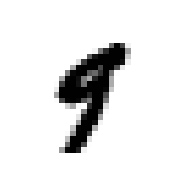

In [5]:
import matplotlib
import matplotlib.pyplot as plt
some_digit = X[36000]
some_digit_image = some_digit.reshape(28,28)
plt.figure(figsize=(2, 2)) 
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")

In [6]:
y[36000]
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

shuffle will guarantee that all cross-validation folds will be similar. we don't want one fold to be missing some digits

In [7]:
shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]


In [8]:
y_train_5 = (y_train ==5)
y_test_5 = (y_test == 5)

In [9]:
random_seed = 1
torch.manual_seed(random_seed)

In [10]:
import torchvision
batch_size_train = 64  # by default we use a minibatch size of 64 for training.
# You can leave it like that during the subsequent exercises.

batch_size_test = 1000

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./files/', train=True, download=True,
          transform=torchvision.transforms.Compose([
              torchvision.transforms.ToTensor(),
              torchvision.transforms.Normalize( 
                  (0.1307,), (0.3081,)),
                             
          ])),
    batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./files/', train=False, download=True,
          transform=torchvision.transforms.Compose([
              torchvision.transforms.ToTensor(),
              torchvision.transforms.Normalize(
                  (0.1307,), (0.3081,)),
          ])),
    batch_size=batch_size_test, shuffle=True)
    

> The `transform` statement modifies the data before passing them to the model as folllows:
> - Transforms the image to a tensor (of black& white pixels)
> - Nolmalizes the dataset with mean 0.1307 and stdev 0.3081.
> To avoid overfitting we pass the option `shuffle=True` so that the network doesn't use the same minibatche/samples during the training.

In [11]:
examples = list(test_loader)
example_data, example_targets = examples[0]
print(example_data.shape)
print(example_targets.shape)

torch.Size([1000, 1, 28, 28])
torch.Size([1000])


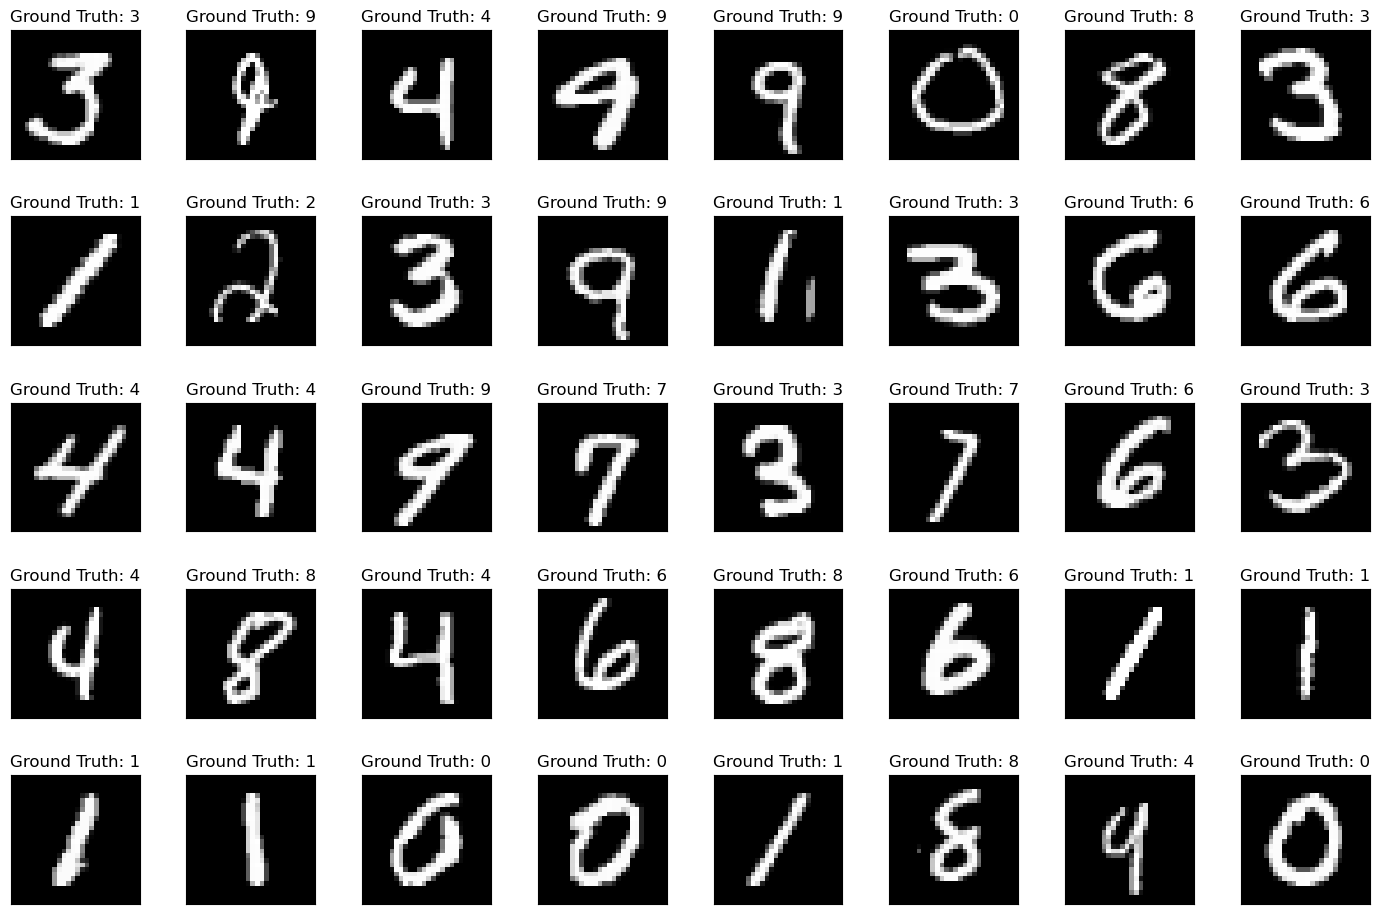

In [15]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 10))
for i in range(40):
  plt.subplot(5,8,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])

In [17]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(1,10,kernel_size=5)
    self.conv2 = nn.Conv2d(10,20,kernel_size=5,padding=(2,2))
    self.fc1 = nn.Linear(720,50)
    self.fc2 = nn.Linear(50,10)

  def forward(self, x):
    # print(x.shape) # (1,28,28)
    x = F.relu(F.max_pool2d(self.conv1(x),2))
    # print(x.shape) # (10,12,12)
    x = F.relu(F.max_pool2d(self.conv2(x),2))
    # print(x.shape) # (20,6,6)
    x = x.view(-1,720) # reshape tensor
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [18]:
learning_rate = 0.01

network = Net().to(DEVICE)  # We move the network to the GPU
optimizer = optim.Adam(network.parameters(), lr=learning_rate)

In [19]:
n_epochs = 3  # 3 epochs by default.  Leave it like that throughout the subsequent exercises.

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

In [20]:
log_interval = 10

def train(epoch):
  network.train()
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    data = data.to(DEVICE)
    target = target.to(DEVICE)
    output = network(data)
    loss = F.cross_entropy(output, target)
    loss.backward()
    optimizer.step()
    if batch_idx % log_interval == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(data), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append(
        (batch_idx*64) + ((epoch-1)*len(train_loader.dataset)))

In [41]:
def test():
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data = data.to(DEVICE)
      target = target.to(DEVICE)
      output = network(data)
      test_loss += F.cross_entropy(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
# test()

In [42]:
test()
for epoch in range(1, n_epochs + 1):
    train(epoch)
    test()

/usr/lib/python3.14/site-packages/torch/nn/functional.py:3503: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.3044, Accuracy: 981/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.318732
Train Epoch: 1 [640/60000 (1%)]	Loss: 0.828528
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.349030
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.295624
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.294979
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.255487
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.111140
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.065923
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.202402
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.157924
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.101021
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.067257
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.183857
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.111518
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.069481
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.116503
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.284568
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.081787
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.025408
Train Epoch: 1 [12160/

Text(0, 0.5, 'negative log likelihood loss')

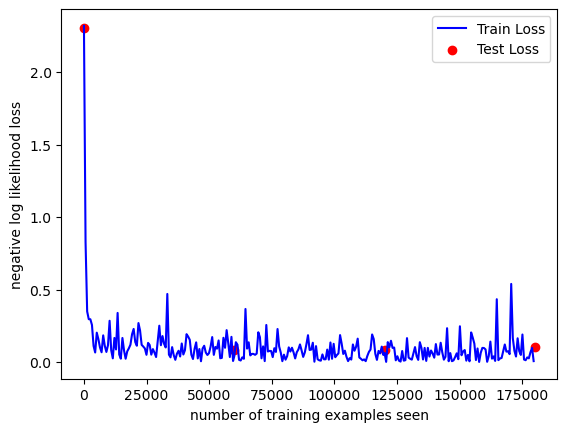

In [43]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.xlabel('number of training examples seen')
plt.ylabel('negative log likelihood loss')

In [21]:
with torch.no_grad():
    output = network(example_data.to(DEVICE))

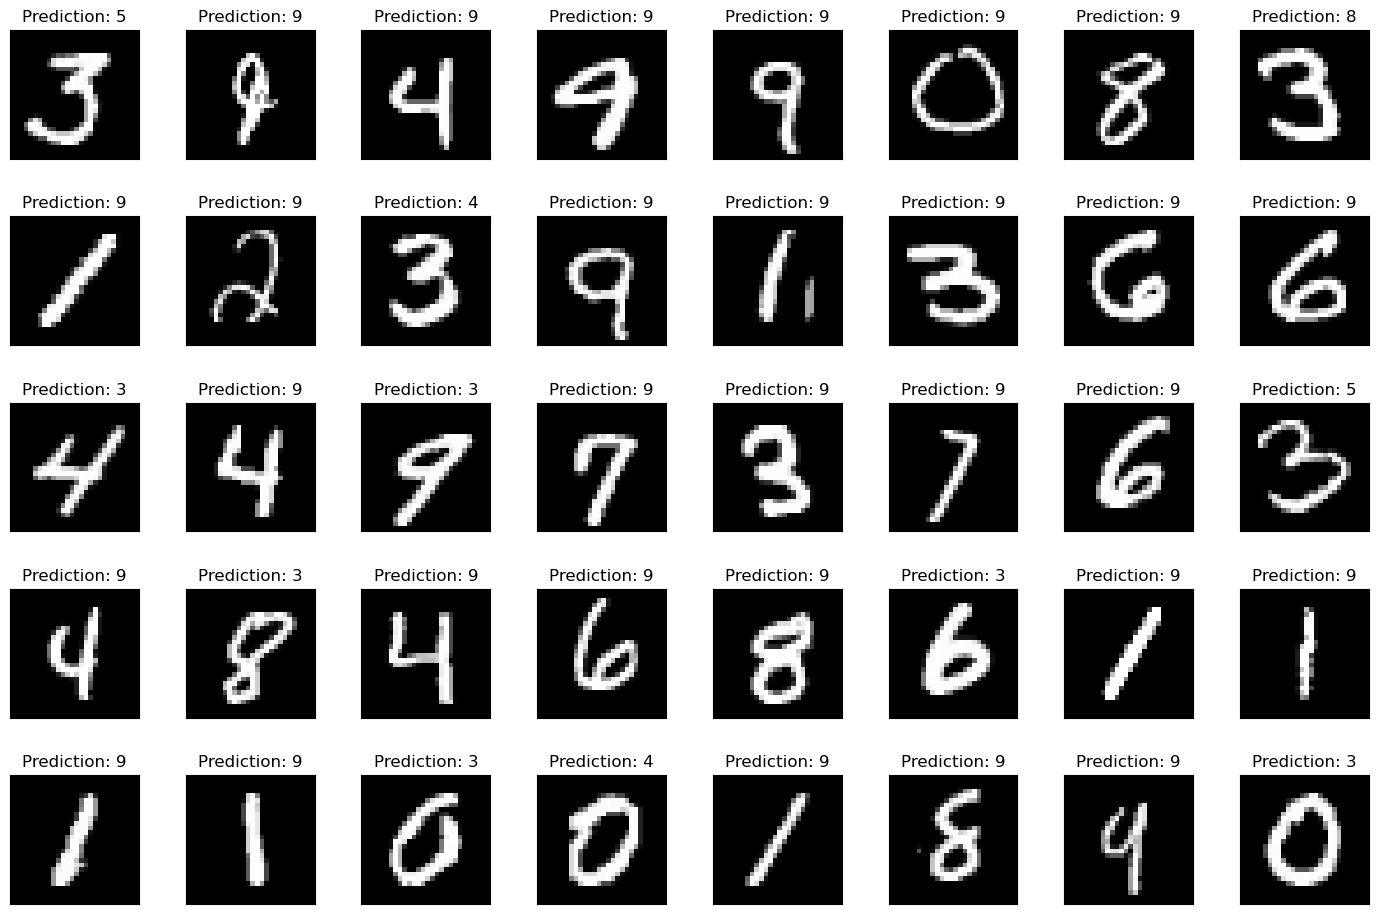

In [22]:
fig = plt.figure(figsize=(14, 10))
for i in range(40):
  plt.subplot(5,8,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
      output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])

## rotate

In [55]:
batch_size_train = 64

batch_size_test = 1000

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)),
                               torchvision.transforms.RandomRotation(180)
                             ])),
                             
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,)),
                               torchvision.transforms.RandomRotation(180)
                             ])),
  batch_size=batch_size_test, shuffle=True)

confirm simple layer network does not perform well for rotated images

In [56]:
learning_rate = 0.01

class Net2(nn.Module):
    def __init__(self):
        super(Net2,self).__init__()
        self.fc = nn.Linear(28*28,10)
    
    def forward(self,x):
        x = self.fc(x.view(-1,28*28))
        return x
        
network = Net2().to(DEVICE)  # We move the network to the GPU
optimizer = optim.Adam(network.parameters(), lr=learning_rate)

n_epochs = 3  # 3 epochs by default.  Leave it like that throughout the subsequent exercises.

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

test()
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()


Test set: Avg. loss: 2.4387, Accuracy: 1008/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.490529
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.880506
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.435256
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.087323
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.595712
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.716274
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.285058
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.766141
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.585310
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.858531
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.474803
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.288433
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.887383
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.597247
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.801699
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.798394
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.779602
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.535208
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.336932
Train Epoch: 1 [12160

cnn


In [ ]:
learning_rate = 0.01

network = Net().to(DEVICE)  # We move the network to the GPU
optimizer = optim.Adam(network.parameters(), lr=learning_rate)
n_epochs = 3  # 3 epochs by default.  Leave it like that throughout the subsequent exercises.

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

test()
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()


Test set: Avg. loss: 2.3060, Accuracy: 1008/10000 (10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.302383
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.295705
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.308308
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.286790
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.224210
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.010376
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.019429
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.798578
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.677243
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.920276
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.703532
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.381065
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.579893
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.495107
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.090380
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.172521
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.338475
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.013284
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.119568
Train Epoch: 1 [12160